In [1]:
import numpy as np
from pythtb import TBModel, WFArray, Mesh, Lattice
from pythtb.utils import levi_civita
import matplotlib.pyplot as plt
from itertools import product

In [2]:
lat_vecs = [[0, 1, 1], [1, 0, 1], [1, 1, 0]]
orb_vecs = [[0, 0, 0], [0.25, 0.25, 0.25]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1, 2])

model = TBModel(lattice=lat, spinful=True)

t = 1.0
soc = 1/4
m = 1/2

model.set_onsite(
    lambda beta: [0, m*np.sin(beta), m*np.sin(beta), m*np.sin(beta)],
    ind_i=0,
)
model.set_onsite(
    lambda beta: [0, -m*np.sin(beta), -m*np.sin(beta), -m*np.sin(beta)],
    ind_i=1,
)

# spin-independent first-neighbor hops
for lvec in ([-1, 0, 0], [0, -1, 0], [0, 0, -1]):
    model.set_hop(t, 0, 1, lvec)

model.set_hop(
    lambda beta: 3 * t + m * np.cos(beta), 
    0, 1, [0, 0, 0], mode="set")

# spin-dependent second-neighbor hops
lvec_list = ([1, 0, 0], [0, 1, 0], [0, 0, 1], [-1, 1, 0], [0, -1, 1], [1, 0, -1])
dir_list = ([0, 1, -1], [-1, 0, 1], [1, -1, 0], [1, 1, 0], [0, 1, 1], [1, 0, 1])
for j in range(6):
    spin = np.array([0.0] + dir_list[j])
    model.set_hop(1j * soc * spin, 0, 0, lvec_list[j])
    model.set_hop(-1j * soc * spin, 1, 1, lvec_list[j])

print(model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 3
k-space dimension           = 3
periodic directions         = [0, 1, 2]
spinful                     = True
number of spin components   = 2
number of electronic states = 4
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 0.000,  1.000,  1.000]
  # 1 ===> [ 1.000,  0.000,  1.000]
  # 2 ===> [ 1.000,  1.000,  0.000]
Volume of unit cell (Cartesian) = 2.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [-3.142,  3.142,  3.142]
  # 1 ===> [ 3.142, -3.142,  3.142]
  # 2 ===> [ 3.142,  3.142, -3.142]
Volume of reciprocal unit cell = 124.025 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.000,  0.000,  0.000]
  # 1 ===> [ 0.500,  0.500,  0.500]
Orbital vectors (fractional):
  # 0 ===> [ 0.000,  0.000,  0.000]
  # 1 ===> [ 0.250,  0.250,  0.250]
----------------------------------------
Site energies:
 

In [3]:
# Varying parameter space
nks = 32, 32, 32
k_flat = np.array(list(product(*[np.linspace(0, 1, nk, endpoint=False) for nk in nks])))

n_beta = 12
max_beta = 2*np.pi
betas = np.linspace(0, max_beta, n_beta, endpoint=False) 

n_param = nks + (n_beta,)    # Number of points in 4d mesh
dim_lam = 1                  # Number of adiabatic dimensions 
dim_k = model.dim_k          # Number of k-space dimensions (3)
dim_total = dim_k + dim_lam  # Total number of dimensions (4)

dq = np.zeros((dim_total, dim_total)) 
np.fill_diagonal(dq[:dim_k, :dim_k], 1 / np.array(nks))
np.fill_diagonal(dq[dim_k:, dim_k:], (2*np.pi) / np.array(n_beta))
d4q = np.linalg.det(dq)

print("(nks, nbeta):", n_param)
print("Total number of parameter points:", np.prod(n_param))
print(f"d^4 q = {d4q}")
print(f"dq = \n {dq}")

(nks, nbeta): (32, 32, 32, 12)
Total number of parameter points: 393216
d^4 q = 1.5978966540475428e-05
dq = 
 [[0.03125    0.         0.         0.        ]
 [0.         0.03125    0.         0.        ]
 [0.         0.         0.03125    0.        ]
 [0.         0.         0.         0.52359878]]


In [4]:
b_curv = model.berry_curvature(
    k_flat, 
    non_abelian=True,
    include_lambda=True, 
    lambda_order=9, 
    beta=betas, 
    use_tensorflow=True
    )

In [5]:
epsilon = levi_civita(4, 4)
c2_density = np.einsum("ijkl, ij...mn, kl...nm->...", epsilon, b_curv, b_curv)

In [6]:
c2 = np.sum(c2_density) * (d4q / (32 * np.pi**2))
print("Second Chern number: ", c2.real)

Second Chern number:  1.0017904026448365


In [7]:
dtheta = np.sum(c2_density, axis=(0)) 

In [8]:
pref = d4q/(16*np.pi)

# your existing cumulative (trapezoid) up to each sampled beta[i]
mid = 0.5*(dtheta[:-1] + dtheta[1:])        # (N-1,)
thetas_kubo = np.empty_like(dtheta, dtype=float)
thetas_kubo[0] = 0.0
thetas_kubo[1:] = np.cumsum(mid.real)
thetas_kubo *= pref                   # scale all partials

# add the closing interval [beta_{N-1} --> 2pi ≡ 0] with periodic trapezoid
theta_2pi = thetas_kubo[-1] + pref * 0.5*(dtheta[-1] + dtheta[0])
thetas_kubo = np.append(thetas_kubo, theta_2pi)
betas_ep = np.append(betas, 2*np.pi)

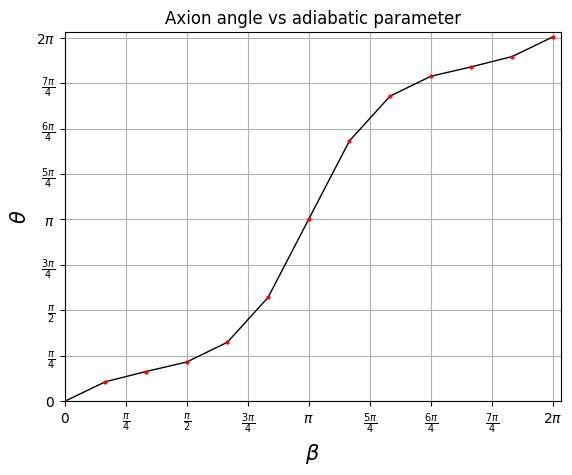

In [9]:
fig, ax = plt.subplots()

ax.set_xlabel(r"$\beta$", size=15)
ax.set_ylabel(r"$\theta$", size=15)

tick_positions = np.arange(0, 2*np.pi+np.pi/4, np.pi/4)
tick_labels = [
    r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
    r"$\frac{5\pi}{4}$", r"$\frac{6\pi}{4}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]

# Set the ticks and labels for both axes
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.set_ylim(0, 2*np.pi+0.1)
ax.set_xlim(0, 2*np.pi+0.1) 

## Riemann sum
ax.plot(betas_ep, thetas_kubo.real, lw=1, zorder=2, c='k')  
ax.scatter(betas_ep, thetas_kubo.real, s=4, zorder=2, c='r')

ax.grid()
ax.set_title("Axion angle vs adiabatic parameter", size=12)
plt.show()